In [1]:
import ufl
import gmsh
import adios4dolfinx
import numpy as np
import pyvista as pv
import dolfinx.io as dio

from ufl import grad, nabla_grad, div, inner, dot, dx
from dolfinx.nls.petsc import NewtonSolver
from dolfinx.fem.petsc import LinearProblem, NonlinearProblem
from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from basix.ufl import element, mixed_element
from petsc4py import PETSc


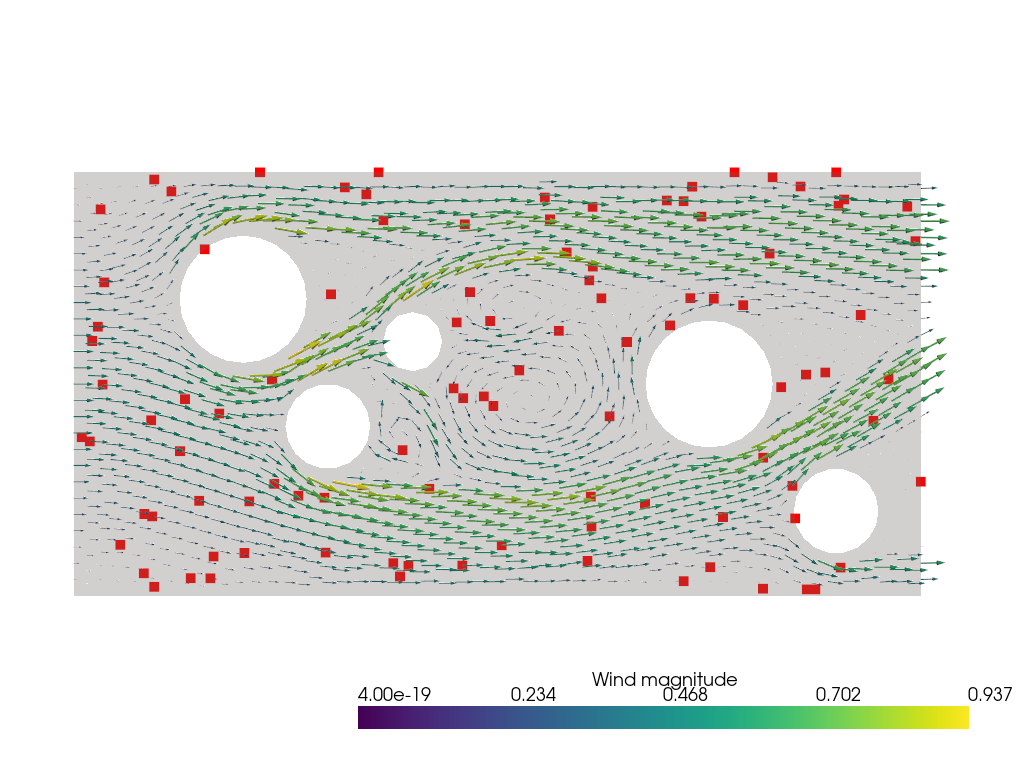

: 

In [ ]:
wind_file = Path("../wind_data/airflow_picard.bp")
domain = adios4dolfinx.read_mesh(wind_file, MPI.COMM_WORLD)
domain.topology.create_connectivity(domain.topology.dim - 1, domain.topology.dim)

topology, cell_type, geom = plot.vtk_mesh(domain)
grid = pv.UnstructuredGrid(topology, cell_type, geom)

elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

mixed_elem = mixed_element([elem_u, elem_p])
W = fem.functionspace(domain, mixed_elem)
W_u, map_u = W.sub(0).collapse() 
W_p, map_p = W.sub(1).collapse()

# Load true velocity fields in P2 and P1
u_true = fem.Function(W_u)
adios4dolfinx.read_function(wind_file, u_true, name="velocity_H2")

# Random P2 samples
coords_P2 = W_u.tabulate_dof_coordinates()
p = 100
rng = np.random.default_rng(1)
sample_ids = rng.choice(len(coords_P2), size=p, replace=False)

x_ids = sample_ids * 2
y_ids = sample_ids * 2 + 1
value_ids = np.stack((x_ids, y_ids)).T.flatten()

measured_fun = fem.Function(W_u)
measured_fun.x.array[:] = 0.0
measured_fun.x.array[value_ids] = u_true.x.array[value_ids]

# --- Prepare visualization of wind field and sampled points ---
sample_points_2d = coords_P2[sample_ids, :2]
sample_points_3d = np.column_stack((sample_points_2d, np.zeros(p)))

# Additional P1 space for wind visualization
V_vis = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1, shape=(2,))) 
u_true_vis = fem.Function(V_vis)
adios4dolfinx.read_function(wind_file, u_true_vis, name="velocity_H1")

wind2d = u_true_vis.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d

subset = grid.extract_points(np.arange(grid.n_points))
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=0.1)

measured = pv.PolyData(sample_points_3d)

# --- Plot ---
pl = pv.Plotter()
pl.add_mesh(grid, color="gray", opacity=0.3)
pl.add_mesh(glyphs, scalar_bar_args={"title": "Wind magnitude"})
pl.add_mesh(measured, color="red", point_size=10, label="Sample DOFs (P2)")
pl.view_xy()
pl.zoom_camera(1.3)
pl.show()

In [72]:
# Define KKT space W x W
W_KKT = fem.functionspace(domain, mixed_element([elem_u, elem_p, elem_u, elem_p]))

W_KKT0 = W_KKT.sub(0)
W_KKT1 = W_KKT.sub(1)
W_KKT2 = W_KKT.sub(2)
W_KKT3 = W_KKT.sub(3)
KKT_u, _ = W_KKT0.collapse()
KKT_p, _ = W_KKT1.collapse()
KKT_l, _ = W_KKT2.collapse()
KKT_m, _ = W_KKT3.collapse()

w = fem.Function(W_KKT) 
u, p, lam, mu = ufl.split(w)

w_old = fem.Function(W_KKT) 
u_old, p_old, lam_old, mu_old = ufl.split(w_old)

# Mask function for for selected measurements
sample_mask_fun = fem.Function(W_u)
sample_mask_fun.x.array[:] = 0.0
sample_mask_fun.x.array[value_ids] = 1.0

# Copy measured values and mask into KKT space
measured_kkt = fem.Function(KKT_u)
measured_kkt.x.array[:] = measured_fun.x.array[:]

mask_kkt = fem.Function(KKT_u)
mask_kkt.x.array[:] = sample_mask_fun.x.array[:]

def misfit(u_c: ufl.core.expr.Expr, measured_fun: fem.Function, mask_c: fem.Function):
    diff = ufl.as_vector([mask_c * (u_c[i] - measured_fun[i]) for i in range(u_c.ufl_shape[0])])

    return 0.5 * ufl.inner(diff, diff) * ufl.dx

nu = fem.Constant(domain, 1.5e-3)

pde_term = (
    nu * inner(grad(u), grad(lam))
    + inner(dot(u_old, grad(u)), lam)
    - inner(p, ufl.div(lam))
    + inner(div(u), mu)
) * dx 

gamma = 1e-1
reg = 0.5 * gamma * inner(grad(u), grad(u)) * dx
J = misfit(u, measured_fun, sample_mask_fun) + reg 

Lagrange = J + pde_term

# Test functions
dw_kkt = ufl.TestFunction(W_KKT)
du, dp, dlam, dmu = ufl.split(dw_kkt)

# Compute variations
dL_du = ufl.derivative(Lagrange, u, du)
dL_dp = ufl.derivative(Lagrange, p, dp)
dL_dlam = ufl.derivative(Lagrange, lam, dlam)
dL_dmu = ufl.derivative(Lagrange, mu, dmu)

# Total residual
F_kkt = dL_du + dL_dp + dL_dlam + dL_dmu

In [73]:
# Load facet tags to assign boundary conditions
meshfile = Path("../meshes/rectangle_circular_holes/mesh.msh").resolve()

_, _, facet_tags = dio.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)

# Get tags of physical groups
gmsh.initialize()
gmsh.open(str(meshfile))
phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

print(name_to_id)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1594 nodes
Info    : 3196 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}


In [74]:
# Primal BC
u_D_no_slip = fem.Function(KKT_u)
u_D_no_slip.x.array[:] = 0.0
no_slip_names = ["Walls", "Obstacle1", "Obstacle2", "Obstacle3", "Obstacle4", "Obstacle5"]
dofs_local_no_slip = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_names])
dofs = fem.locate_dofs_topological((W_KKT0, KKT_u), KKT_u.mesh.topology.dim - 1, dofs_local_no_slip)

bc_no_slip = fem.dirichletbc(u_D_no_slip, dofs, W_KKT0)

u_D_p = fem.Function(KKT_p)
u_D_p.x.array[:] = 0.0
names_p_zero = ["Outflow"]
dofs_p_zero = np.concatenate([facet_tags.find(name_to_id[name]) for name in names_p_zero])
dofs = fem.locate_dofs_topological((W_KKT1, KKT_p), KKT_p.mesh.topology.dim - 1, dofs_p_zero)

bc_p_zero = fem.dirichletbc(u_D_p, dofs, W_KKT1)

# Adjoint BCs
u_D_no_slip_adj = fem.Function(KKT_l)
u_D_no_slip_adj.x.array[:] = 0.0
dofs = fem.locate_dofs_topological((W_KKT2, KKT_l), KKT_l.mesh.topology.dim - 1, dofs_local_no_slip)

bc_no_slip_adj = fem.dirichletbc(u_D_no_slip_adj, dofs, W_KKT2)

u_D_m = fem.Function(KKT_m)
u_D_m.x.array[:] = 0.0
dofs = fem.locate_dofs_topological((W_KKT3, KKT_m), KKT_m.mesh.topology.dim - 1, dofs_p_zero)

bc_m_zero = fem.dirichletbc(u_D_m, dofs, W_KKT3)

In [75]:
max_iter = 5
tol = 1e-8
omega = 0.2

# Initial guess
w.x.array[:] = 0.0
w_old.x.array[:] = 0.0

for k in range(max_iter):
    print(f"\n--- Picard iteration {k+1} ---")

    # SUPG params
    h = ufl.CellDiameter(domain)
    abs_u_prev = ufl.sqrt(ufl.dot(u_old, u_old)) + 1e-12
    tau = 1.0 / ( (2.0 * abs_u_prev) / h + 4.0 * nu / (h*h) + 1e-8 )
    Rm_trial = ufl.dot(u_old, nabla_grad(u)) - nu * div(nabla_grad(u)) + nabla_grad(p)
    supg = tau * ufl.inner(ufl.dot(u_old, ufl.nabla_grad(lam)), Rm_trial) * dx

    pde_term = (
        nu * inner(grad(u), grad(lam))
        + inner(dot(u_old, grad(u)), lam)
        - inner(p, div(lam))
        + inner(div(u), mu)
    ) * dx + supg

    J = misfit(u, measured_kkt, mask_kkt) + 0.5 * gamma * inner(grad(u), grad(u)) * dx
    Lagrange = J + pde_term

    dw = ufl.TestFunction(W_KKT)
    du, dp, dlam, dmu = ufl.split(dw)

    dL_du   = ufl.derivative(Lagrange, u, du)
    dL_dp   = ufl.derivative(Lagrange, p, dp)
    dL_dlam = ufl.derivative(Lagrange, lam, dlam)
    dL_dmu  = ufl.derivative(Lagrange, mu, dmu)

    F_kkt = dL_du + dL_dp + dL_dlam + dL_dmu

    # Linearization in the current iteration
    w_trial = ufl.TrialFunction(W_KKT)
    dw_test = ufl.TestFunction(W_KKT)

    a = ufl.derivative(F_kkt, w, w_trial)
    L = -ufl.action(F_kkt, dw_test)

    # Build linear problem
    problem = LinearProblem(
        a, L,
        bcs=[bc_no_slip, bc_p_zero, bc_no_slip_adj, bc_m_zero],
        petsc_options={"ksp_type": "gmres", "pc_type": "lu", "ksp_monitor": None}
    )

    w_new = problem.solve()

    # Check convergence
    diff = np.linalg.norm(w_new.x.array - w_old.x.array)
    print(f"‣ residual norm = {diff:.3e}")
    if diff < tol:
        print("Converged!")
        break

    # Update w_old
    w_old.x.array[:] = (1 - omega) * w_old.x.array + omega * w_new.x.array
    w.x.array[:] = w_new.x.array[:]


--- Picard iteration 1 ---
‣ residual norm = inf

--- Picard iteration 2 ---
‣ residual norm = nan

--- Picard iteration 3 ---
‣ residual norm = nan

--- Picard iteration 4 ---
‣ residual norm = nan

--- Picard iteration 5 ---
‣ residual norm = nan
